<a href="https://colab.research.google.com/github/yuhui-0611/ESAA/blob/main/ESAA_WEEK12_1_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Neural Networks in Tensorflow with Titanic**

[link text](https://www.kaggle.com/code/saumandas/neural-networks-in-tensorflow-with-titanic)

In [4]:
import numpy as np
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
train_df = pd.read_csv('/content/drive/MyDrive/ESAA/Neural Networks/train.csv')

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
train_df.loc[0]

,0
PassengerId,1
Survived,0
Pclass,3
Name,"Braund, Mr. Owen Harris"
Sex,male
Age,22.0
SibSp,1
Parch,0
Ticket,A/5 21171
Fare,7.25


In [9]:
# Drop Name and Ticket
train_df.drop(['Name', 'Ticket', 'PassengerId', 'Cabin'], axis=1, inplace=True)  # 열 삭제
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


| 제거하는 열        | 제거 이유                                   |
| ------------- | --------------------------------------- |
| `Name`        | 승객 이름. 그대로는 숫자 모델에 넣기 어렵고, 여기서는 사용하지 않음 |
| `Ticket`      | 티켓 번호. 문자열이고 규칙성이 복잡해서 기본 모델에서는 제거      |
| `PassengerId` | 승객 고유 번호. 생존 여부와 직접적인 관계가 거의 없음         |
| `Cabin`       | 객실 번호. 결측치가 많아서 기본 전처리에서는 제거            |


In [10]:
X = train_df.drop('Survived', axis=1, inplace=False)
y = train_df['Survived']

print(f'Input features shape: {X.shape}')
print(f'Labels shape: {y.shape}')

Input features shape: (891, 7)
Labels shape: (891,)


| Survived 값 | 의미 |
| ---------- | -- |
| 0          | 사망 |
| 1          | 생존 |


In [11]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

Text(0, 0.5, 'Number of Passengers')

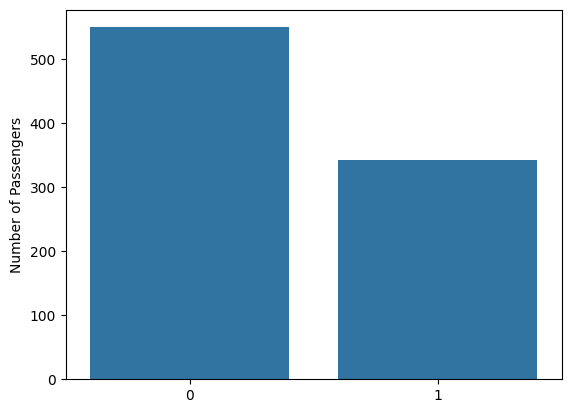

In [13]:
# 생존자/사망자 수 시각화
sns.barplot(x = y.unique(), y = y.value_counts())
# y.unique() : y에 들어 있는 고유한 값들을 반환
plt.ylabel('Number of Passengers')

   Pclass  Sex  Age  SibSp  Parch  Fare  Embarked
0     891  891  714    891    891   891       889


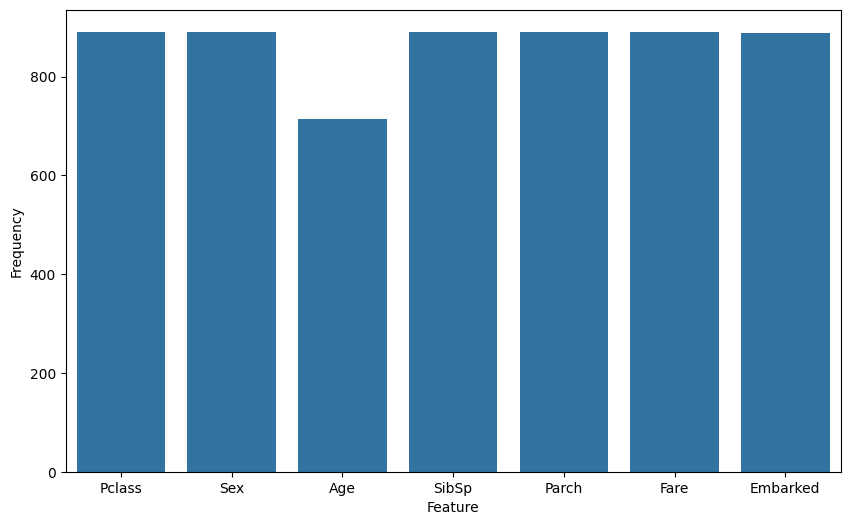

In [14]:
# 각 변수의 결측치가 아닌 값 개수 확인
frequencies = X.count()  # 결측치가 아닌 값의 개수
freq_df = pd.DataFrame([frequencies], columns=X.columns)
print(freq_df.head())

plt.figure(figsize=(10, 6))
sns.barplot(x=X.columns, y = frequencies)
plt.ylabel('Frequency')
plt.xlabel('Feature')
plt.show()

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer  # 결측치 채우는 도구
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 숫자형 변수용 파이프라인
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('std_scaler', StandardScaler())
])

# 범주형 변수용 파이프라인
cat_pipeline = Pipeline([
    ('cat_imputer', SimpleImputer(strategy='most_frequent')),
    ('one_hot', OneHotEncoder())
])

- 숫자형 데이터 → 결측치를 중앙값으로 채움 → StandardScaler로 표준화 → 전처리 완료
- 범주형 데이터 → 결측치를 최빈값으로 채움 → 원-핫 인코딩 → 전처리 완료

In [16]:
# 숫자형/범주형 전처리 파이프라인을 하나로 합침
from sklearn.compose import ColumnTransformer

num_attribs = ['Age', 'SibSp', 'Parch', 'Fare']
cat_attribs = ['Pclass', 'Sex', 'Embarked']

full_pipeline = ColumnTransformer([("num", num_pipeline, num_attribs),
                                   ("cat", cat_pipeline, cat_attribs)])
X = full_pipeline.fit_transform(X)
X.shape

(891, 12)

- 원래 변수가 7개였는데, 전처리 후 열 개수는 12개가 됨
  - 범주형의 원핫 인코딩 때문

In [17]:
full_pipeline

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('std_scaler',
                                                  StandardScaler())]),
                                 ['Age', 'SibSp', 'Parch', 'Fare']),
                                ('cat',
                                 Pipeline(steps=[('cat_imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('one_hot', OneHotEncoder())]),
                                 ['Pclass', 'Sex', 'Embarked'])])

- ColumnTransformer : 열마다 서로 다른 전처리를 적용하게 해줌
  - Age, SibSp, Parch, Fare에는 숫자형 전처리 적용
  - Pclass, Sex, Embarked에는 범주형 전처리 적용

In [18]:
# 전처리된 X와 정답 y를 train/validation으로 나눔
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# TensorFlow/Keras 라이브러리 불러오기
import tensorflow as tf
from tensorflow import keras  # 더 쉽게 신경망 모델을 만들 수 있게 해줌
from tensorflow.keras.models import Sequential  # 층을 순서대로 쌓음
from tensorflow.keras import layers as L

## Titanic 생존 예측용 신경망 모델

In [22]:
# Sequential 방식의 빈 모델 생성
# 층을 순서대로 하나씩 쌓는 구조
model = Sequential(name='titanic_model')

# 입력층 추가
# 전처리 후 feature 개수가 12개이므로 input_shape=(12,)로 지정
model.add(L.InputLayer(input_shape=(12,)))

# 첫 번째 은닉층
# 512개의 뉴런을 사용하고, 활성화 함수로 ReLU 사용
model.add(L.Dense(512, activation='relu'))

# 두 번째 은닉층
# 1024개의 뉴런을 사용
model.add(L.Dense(1024, activation='relu'))

# Dropout 층
# 학습 중 뉴런의 40%를 무작위로 꺼서 과적합을 줄임
model.add(L.Dropout(0.4))

# 세 번째 은닉층
model.add(L.Dense(512, activation='relu'))

# 다시 Dropout 적용
model.add(L.Dropout(0.4))

# 이후 은닉층들
model.add(L.Dense(128, activation='relu'))
model.add(L.Dense(64, activation='relu'))
model.add(L.Dense(64, activation='relu'))

# 출력층
# Titanic 생존 예측은 0 또는 1을 예측하는 이진 분류 문제
# sigmoid는 출력값을 0~1 사이 확률값으로 바꿔줌
model.add(L.Dense(1, activation='sigmoid'))

# 모델 구조 요약 출력
model.summary()

Model: "titanic_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 512)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,134,913 (4.33 MB)

 Trainable params: 1,134,913 (4.33 MB)

 Non-trainable params: 0 (0.00 B)

- 완전 연결층
  - 이전 층의 모든 값이 다음 층의 모든 뉴런과 연결되는 구조
  - 각 뉴런은 입력값들의 가중합을 계산한 뒤, 활성화 함수를 통과시켜 출력값을 만듦
- ReLU 활성화 함수
  - ReLU(x) = max(0, x)
  - 신경망에 비선형성을 넣기 위해서 사용

In [23]:
model.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(0.0001), metrics=['accuracy'])

- compile() : 모델을 학습시키기 전에 학습 방식을 설정하는 단계

| 항목          | 의미                          |
| ----------- | --------------------------- |
| `loss`      | 모델이 얼마나 틀렸는지 계산하는 기준        |
| `optimizer` | 틀린 정도를 줄이기 위해 가중치를 어떻게 수정할지 |
| `metrics`   | 학습 중 성능을 어떤 지표로 볼지          |

- binary_crossentropy : 이진 분류에서 예측 확률이 정답과 얼마나 다른지를 계산하는 손실 함수
- Adam : 딥러닝에서 많이 쓰이는 최적화 알고리즘
  - loss가 줄어드는 방향으로 가중치를 업데이트하되, 너무 느리거나 너무 불안정하지 않게 조절해주는 방법

In [24]:
class myCallback(tf.keras.callbacks.Callback):  # 모델 학습 중간중간에 자동으로 실행되는 기능
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('val_accuracy')>0.83):  # 검증 정확도 val_accuracy가 0.83을 넘으면 학습을 멈추게 만듦
            print("\nReached 83% accuracy so cancelling training!")
            self.model.stop_training = True
            # epochs=50이라고 되어 있어도,
            # 만약 10번째 epoch에서 val_accuracy가 0.83을 넘으면
            # 그 시점에서 학습이 끝날 수 있음

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    batch_size=8,
                    callbacks=[myCallback()],  # callback을 학습에 적용
                    epochs=50)

Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.7037 - loss: 0.6373 - val_accuracy: 0.7709 - val_loss: 0.5213
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.7949 - loss: 0.4890 - val_accuracy: 0.8156 - val_loss: 0.4412
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8090 - loss: 0.4391 - val_accuracy: 0.8101 - val_loss: 0.4326
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8244 - loss: 0.4142 - val_accuracy: 0.8212 - val_loss: 0.4432
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8216 - loss: 0.4069 - val_accuracy: 0.8212 - val_loss: 0.4357
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.8343 - loss: 0.4066 - val_accuracy: 0.8156 - val_loss: 0.4438
Epoch 7/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8441 - loss: 0.4038 - val_accuracy: 0.8268 - val_loss: 0.4470
Epoch 8/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8371 - loss: 0.3933 - val_accuracy: 0.8212 - v

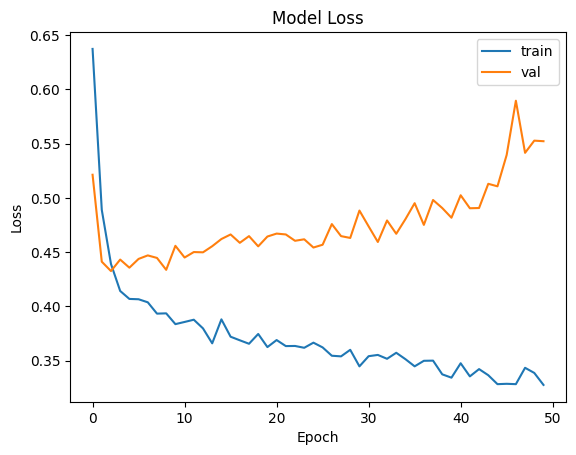

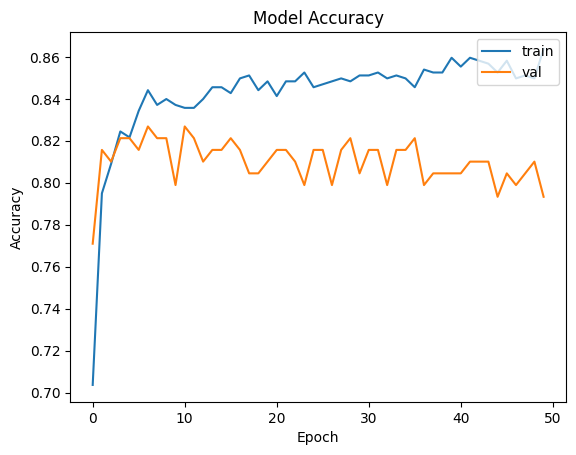

In [25]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['train', 'val'], loc='upper right')
plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['train', 'val'], loc='upper right')
plt.show()

< 이상적인 경우 >
- train accuracy 증가
- val accuracy도 함께 증가
- 두 값의 차이가 너무 크지 않음

< 과적합 의심되는 경우 >
- train accuracy는 계속 증가
- val accuracy는 정체되거나 감소

< 과소적합 의심되는 경우 >
- train accuracy도 낮음
- val accuracy도 낮음

In [26]:
test_df = pd.read_csv('/content/drive/MyDrive/ESAA/Neural Networks/test.csv')
test_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
test_df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S
...,...,...,...,...,...,...,...
413,3,male,NaN,0,0,8.0500,S
414,1,female,39.0,0,0,108.9000,C
415,3,male,38.5,0,0,7.2500,S
416,3,male,NaN,0,0,8.0500,S


In [27]:
test_prepared = full_pipeline.transform(test_df)
test_prepared.shape

(418, 12)

In [28]:
preds = model.predict(test_prepared)
preds[:5]

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


array([[0.0773695 ],
       [0.2272176 ],
       [0.06323557],
       [0.14297292],
       [0.2767875 ]], dtype=float32)